# Decision Tree(의사결정 나무)

## 계속하여 이것인지 저것인지 결정한다.

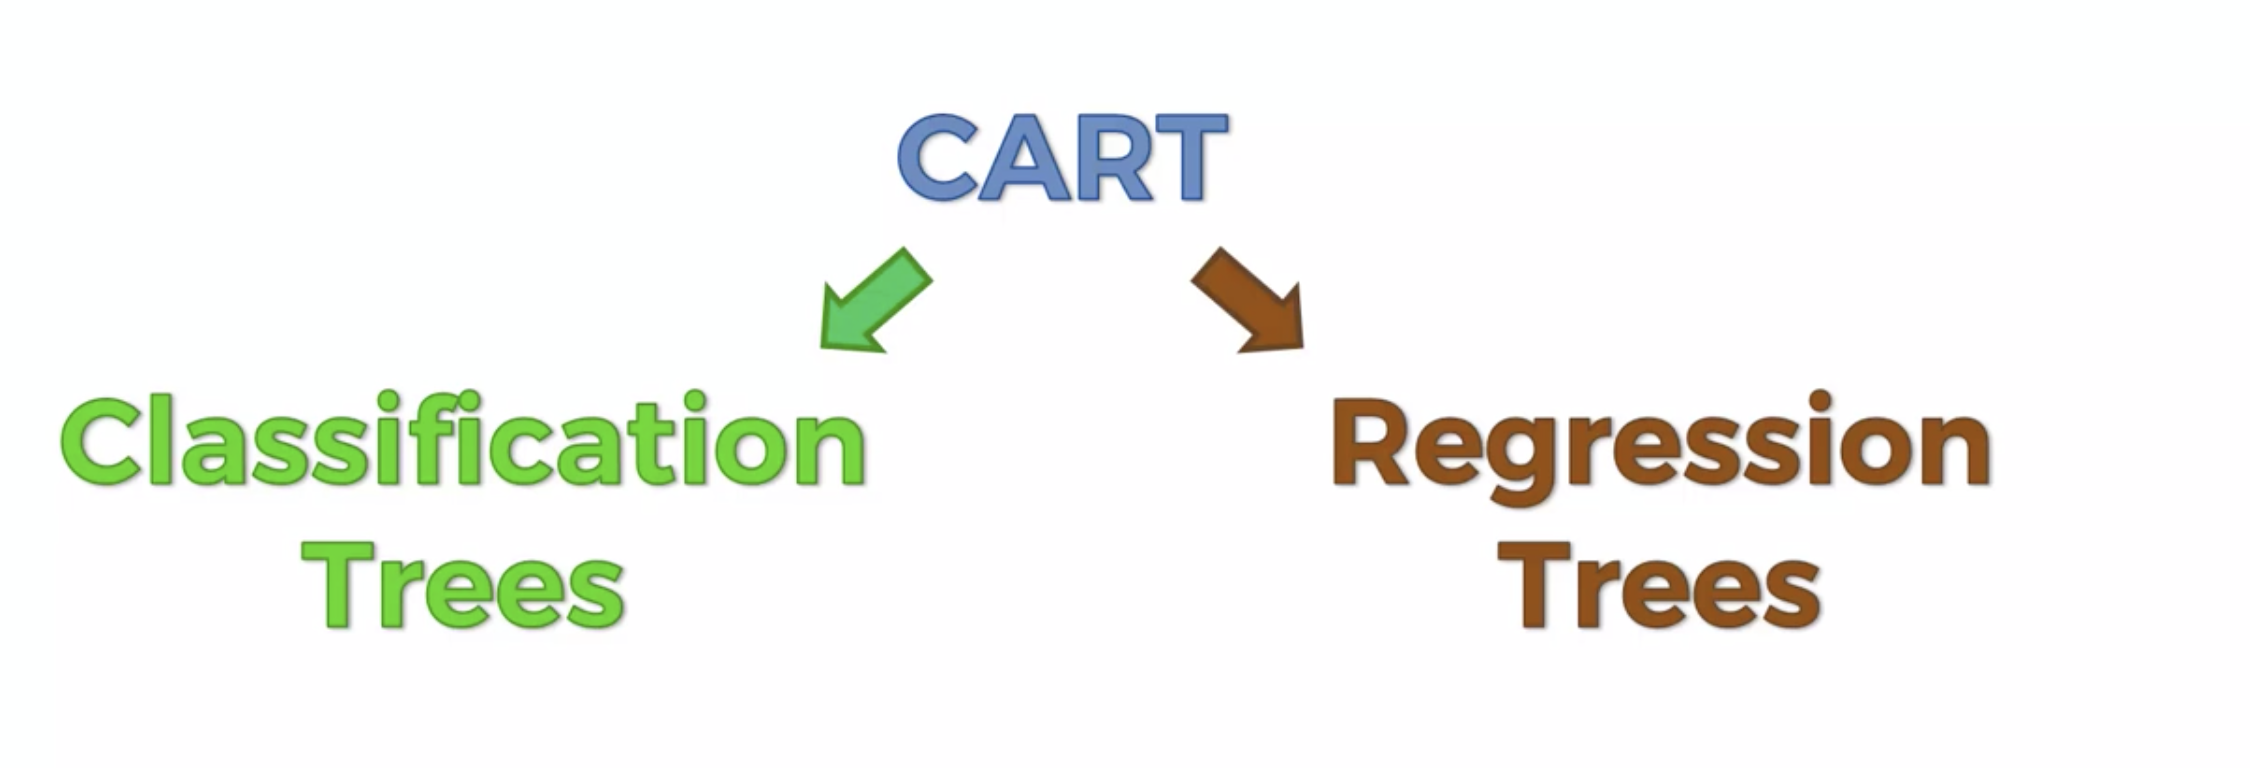

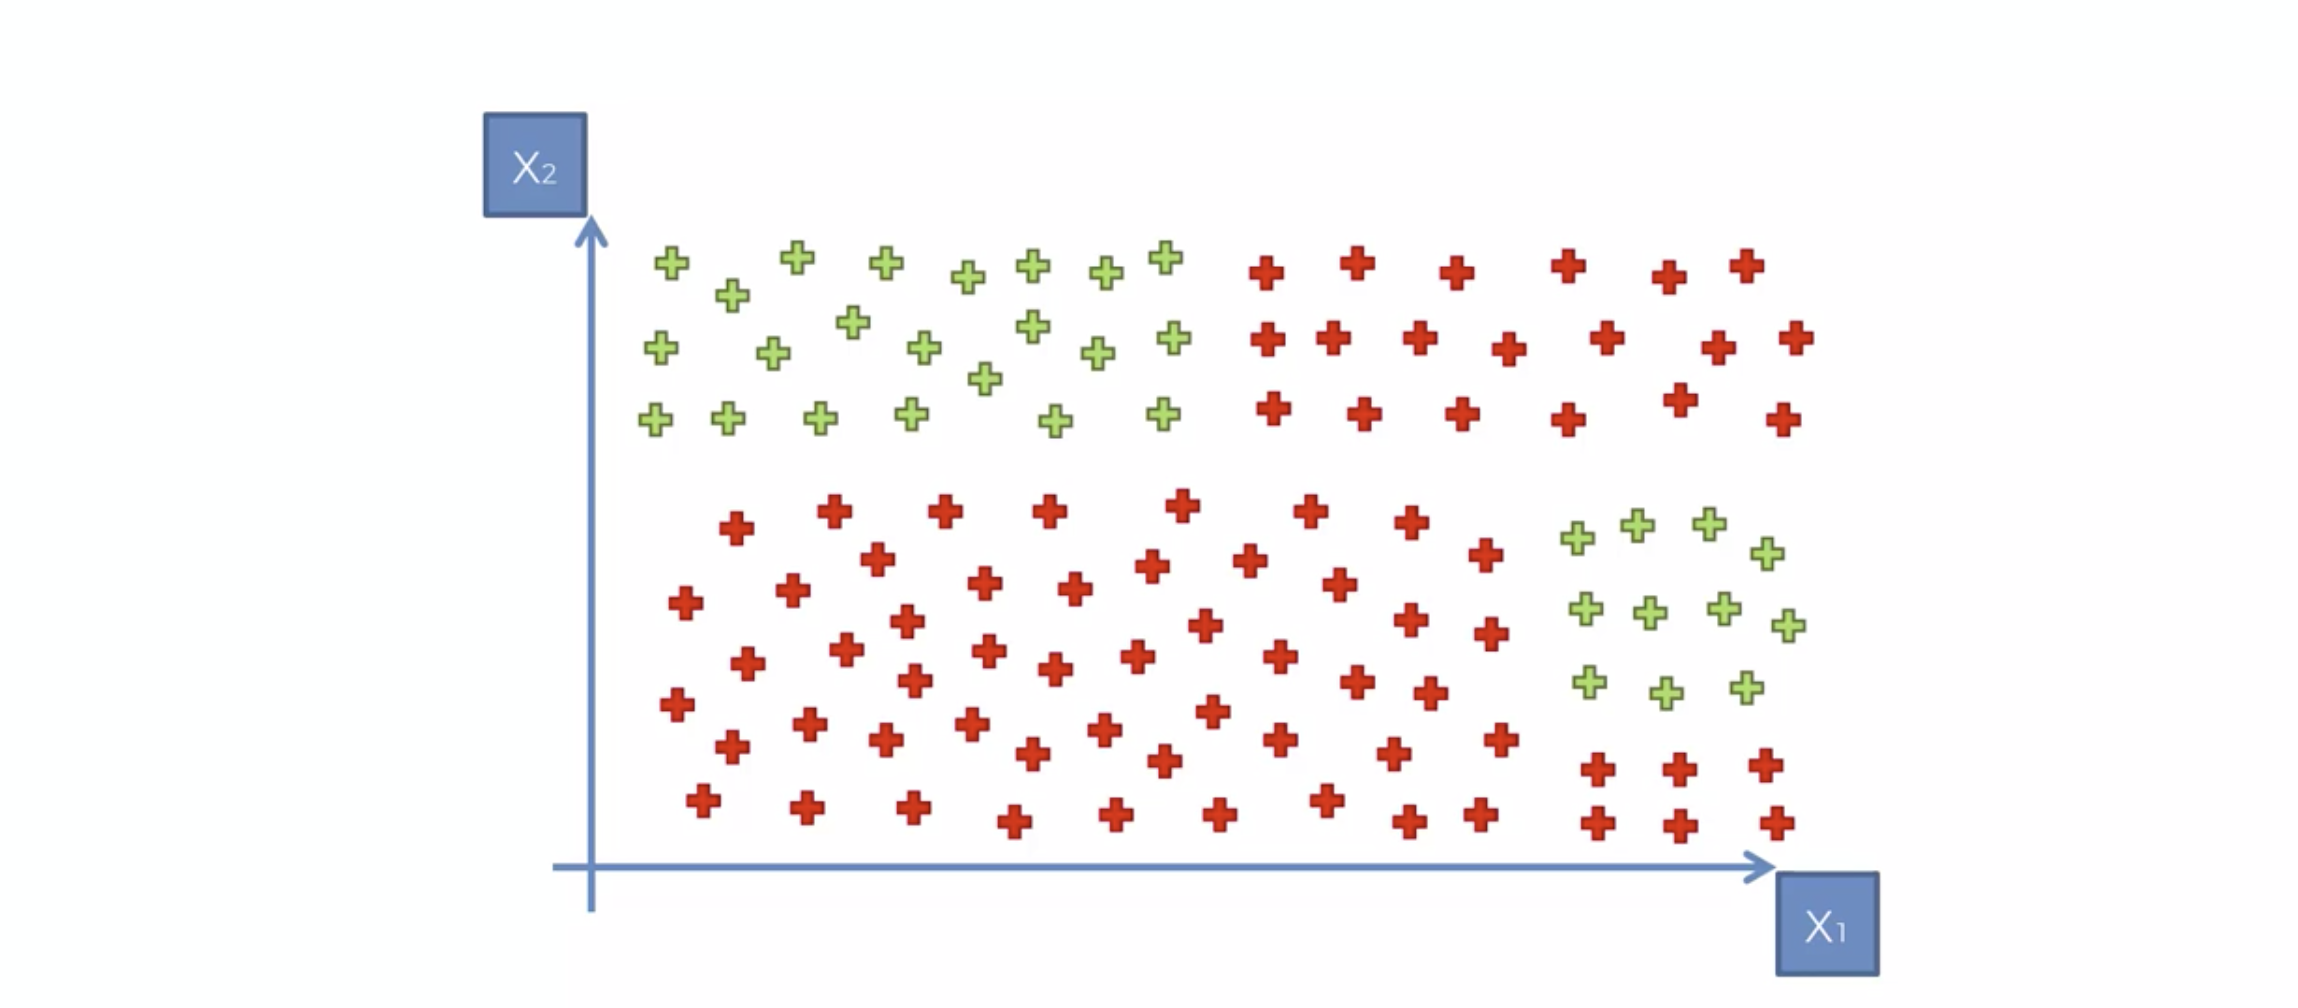

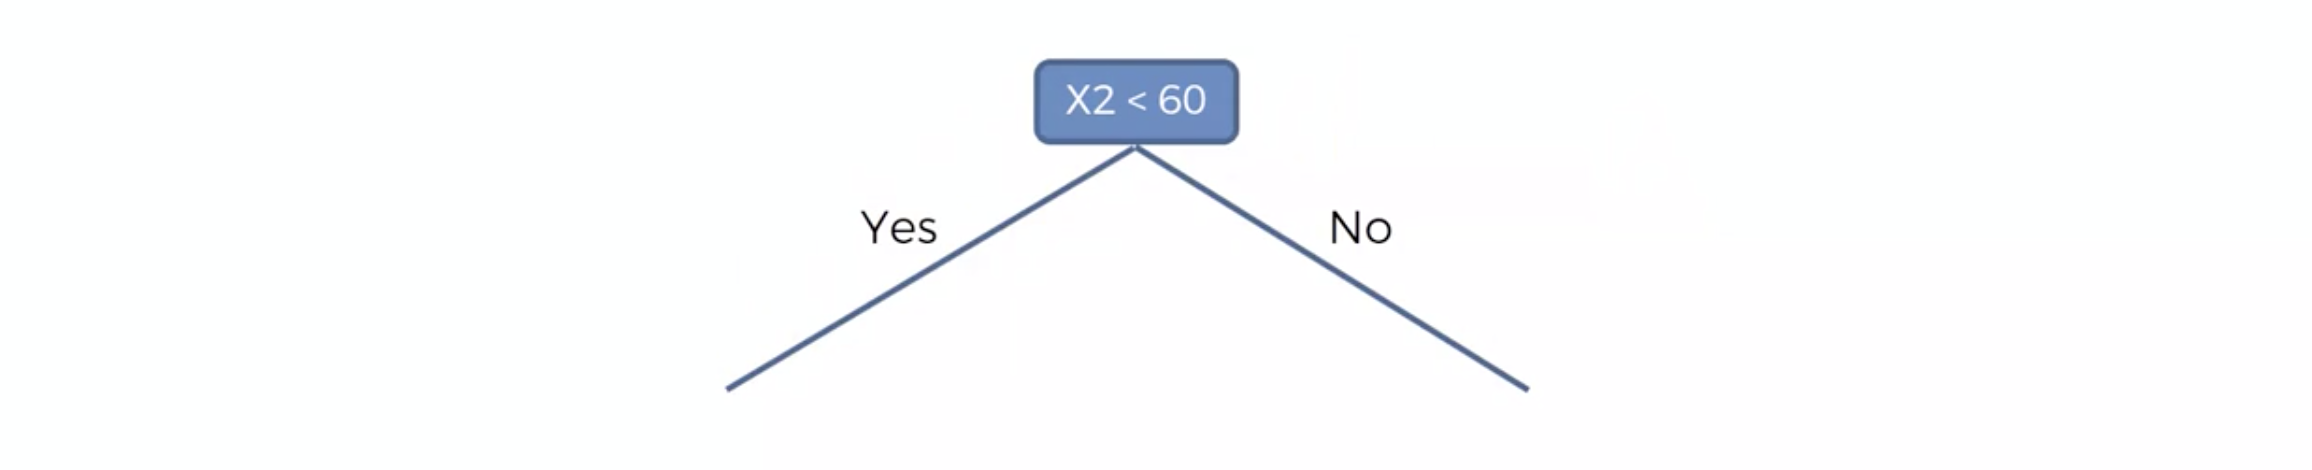

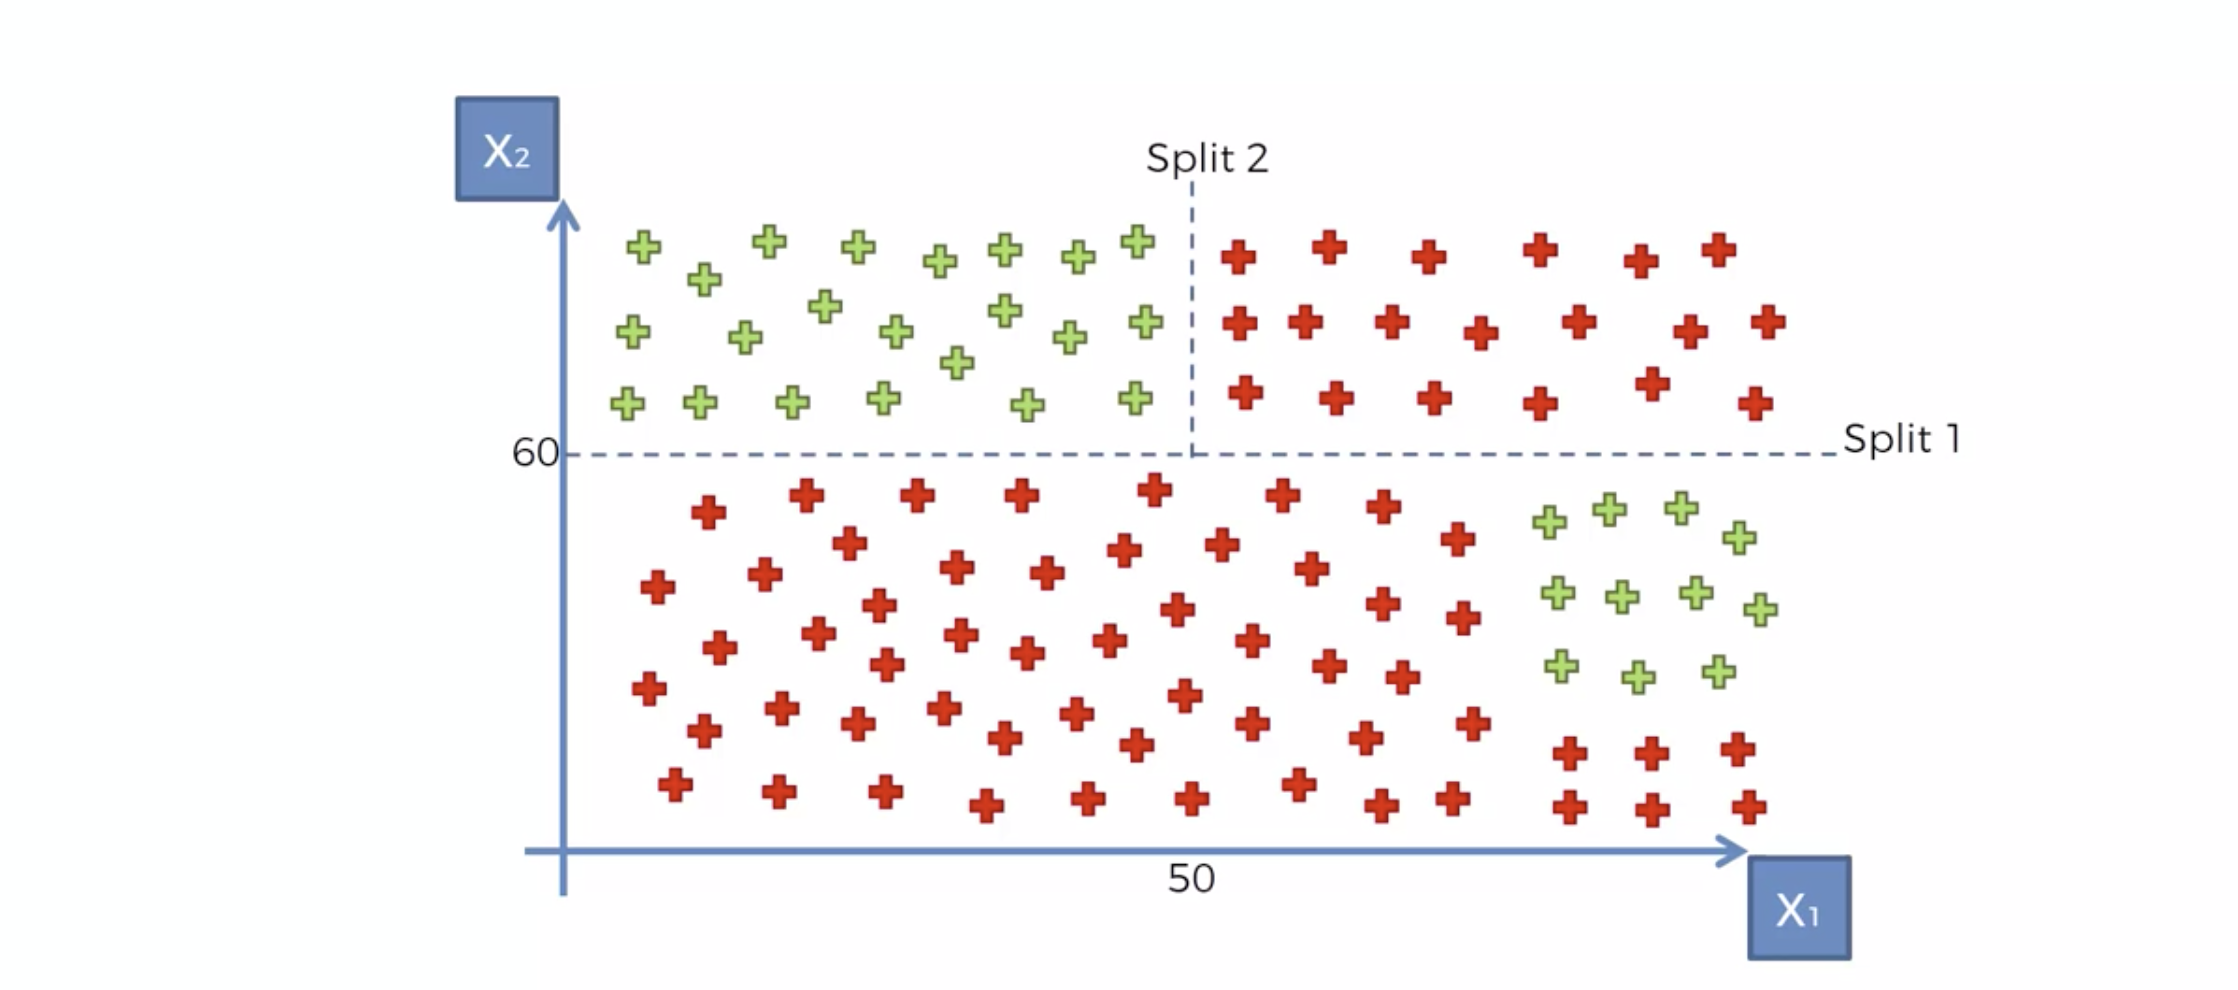

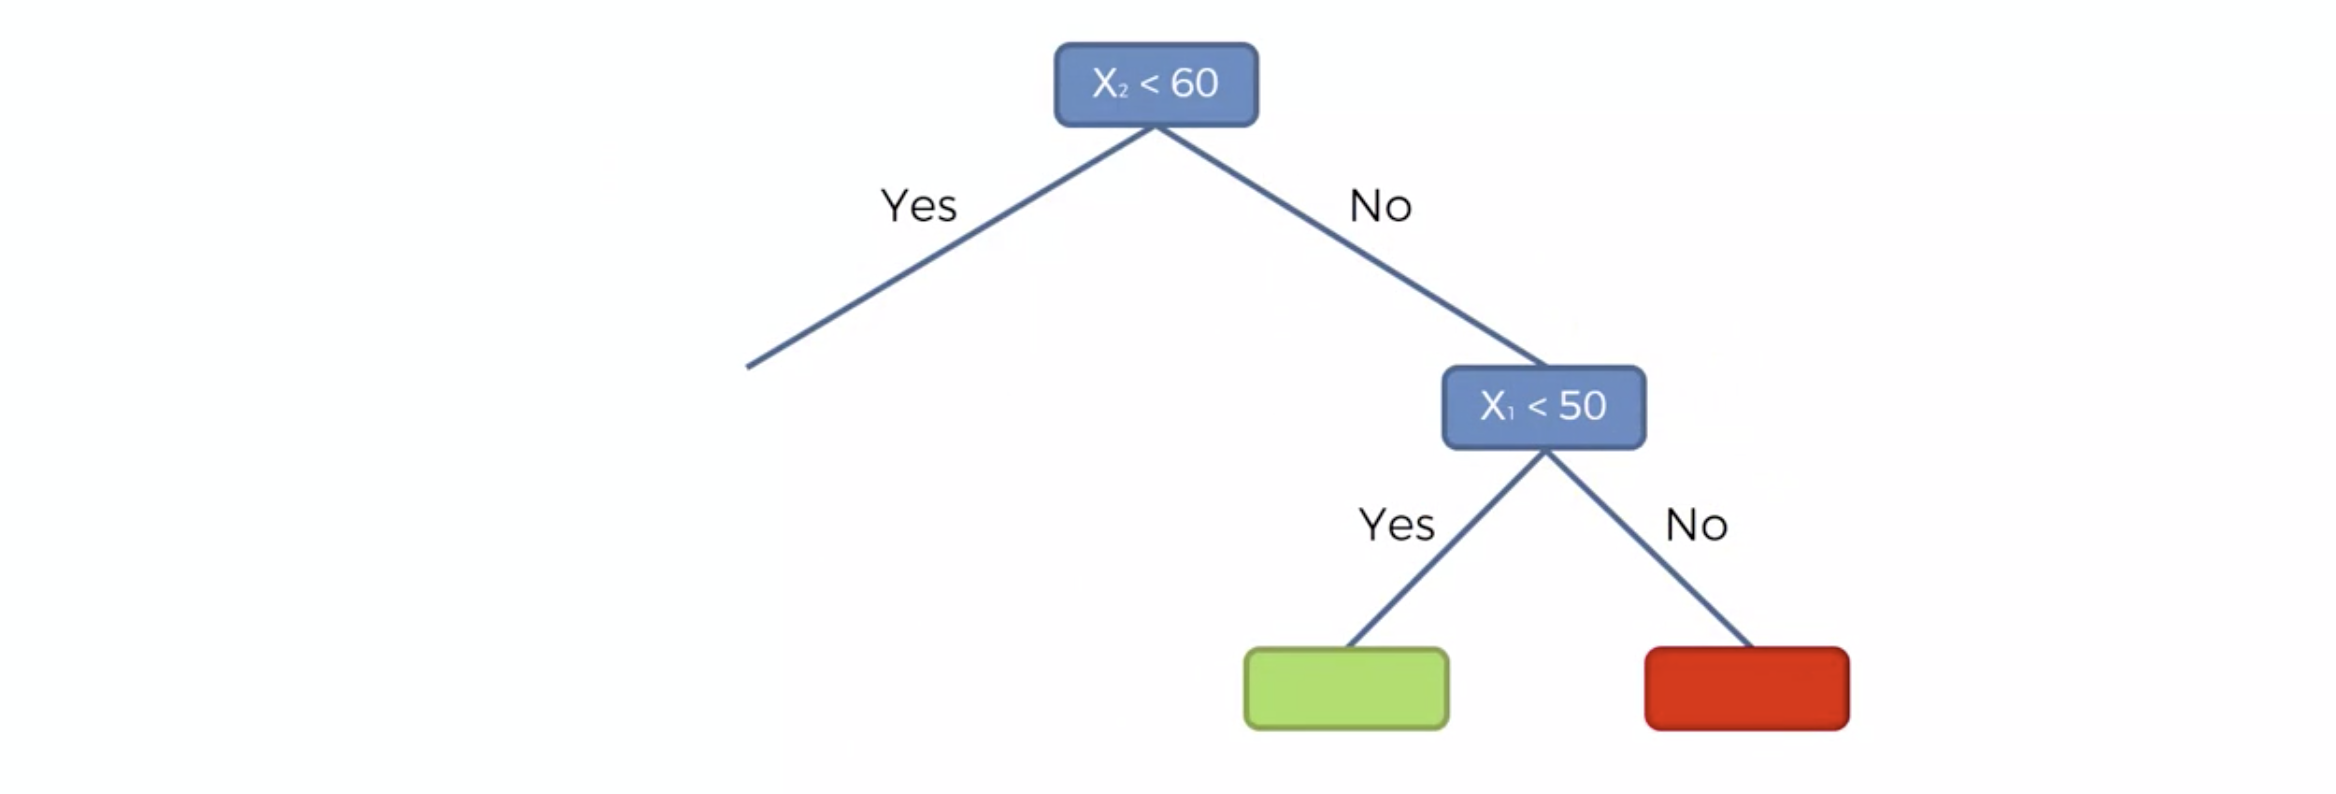

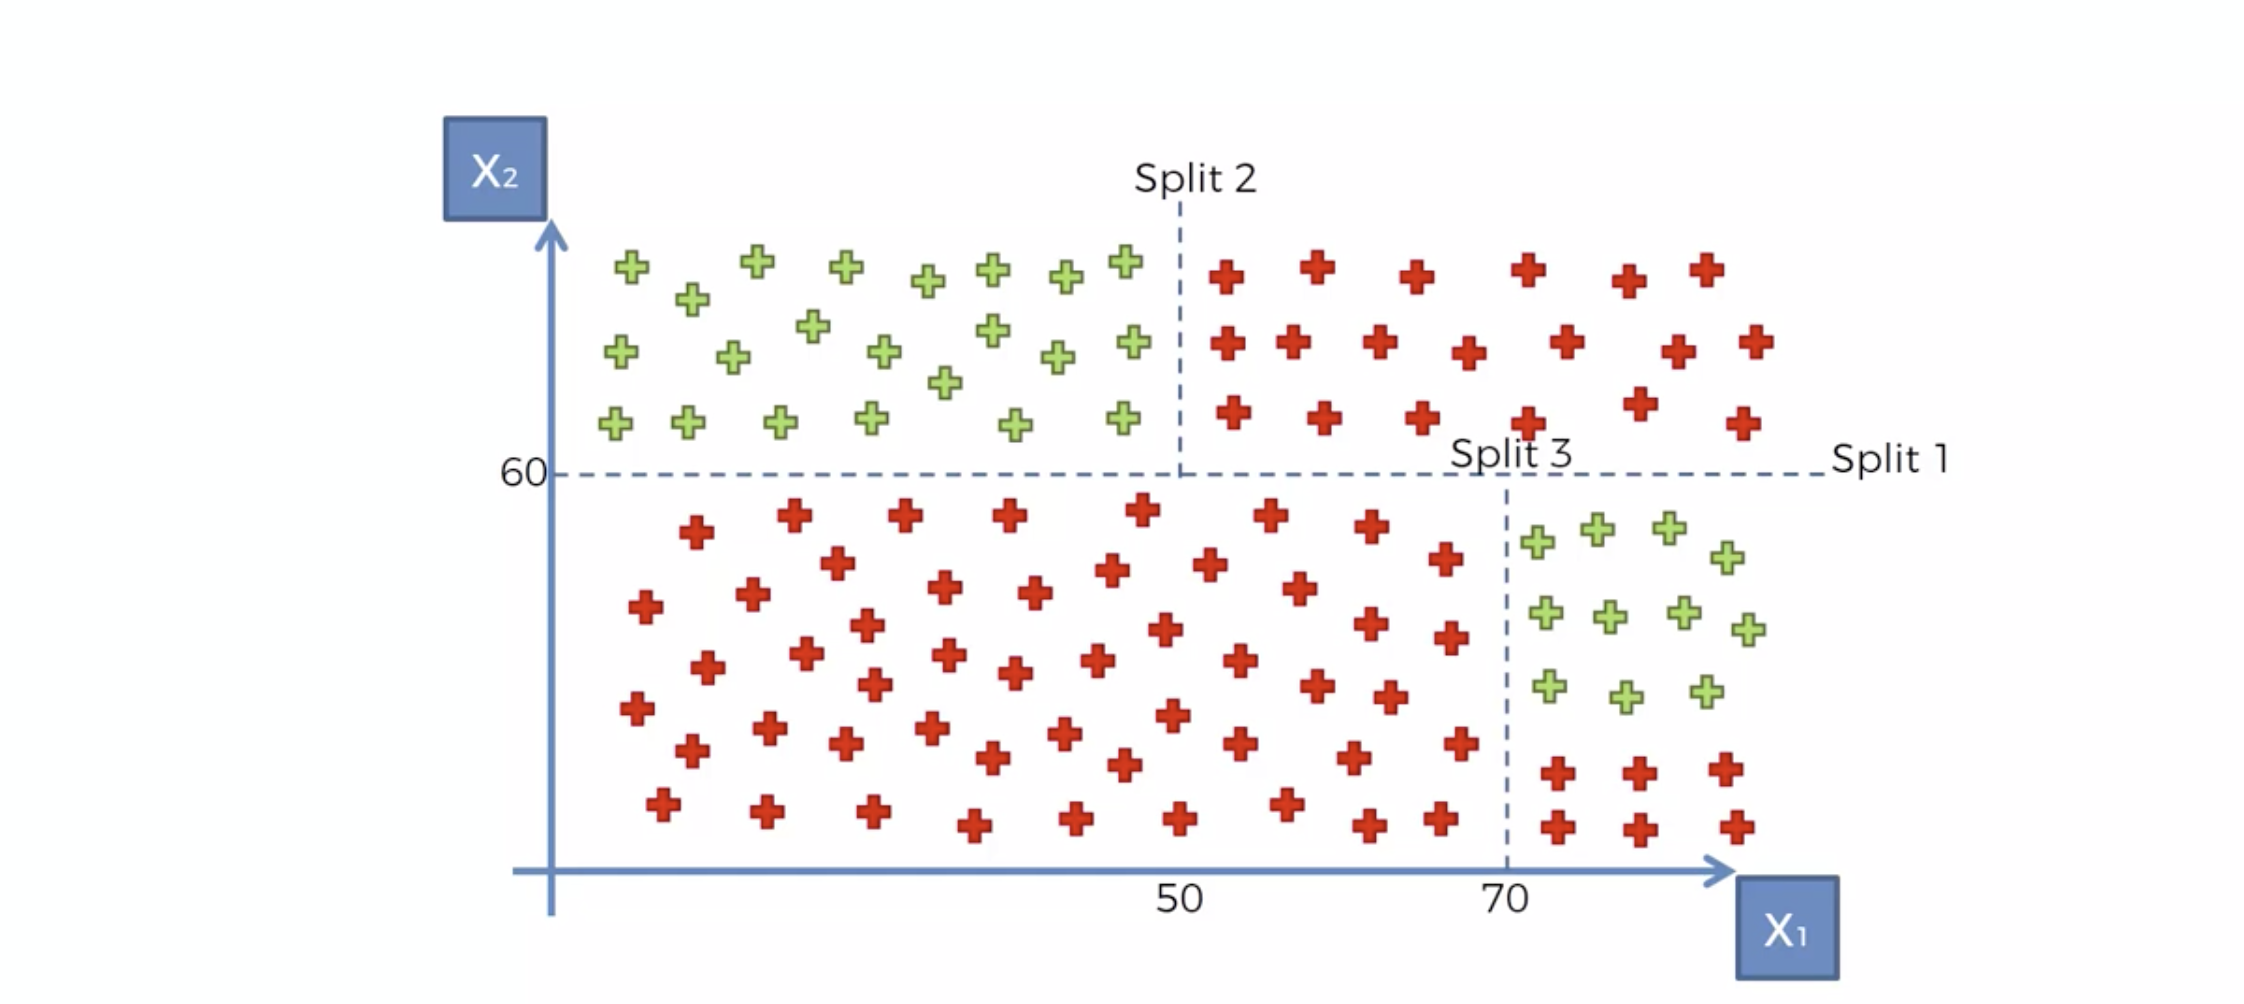

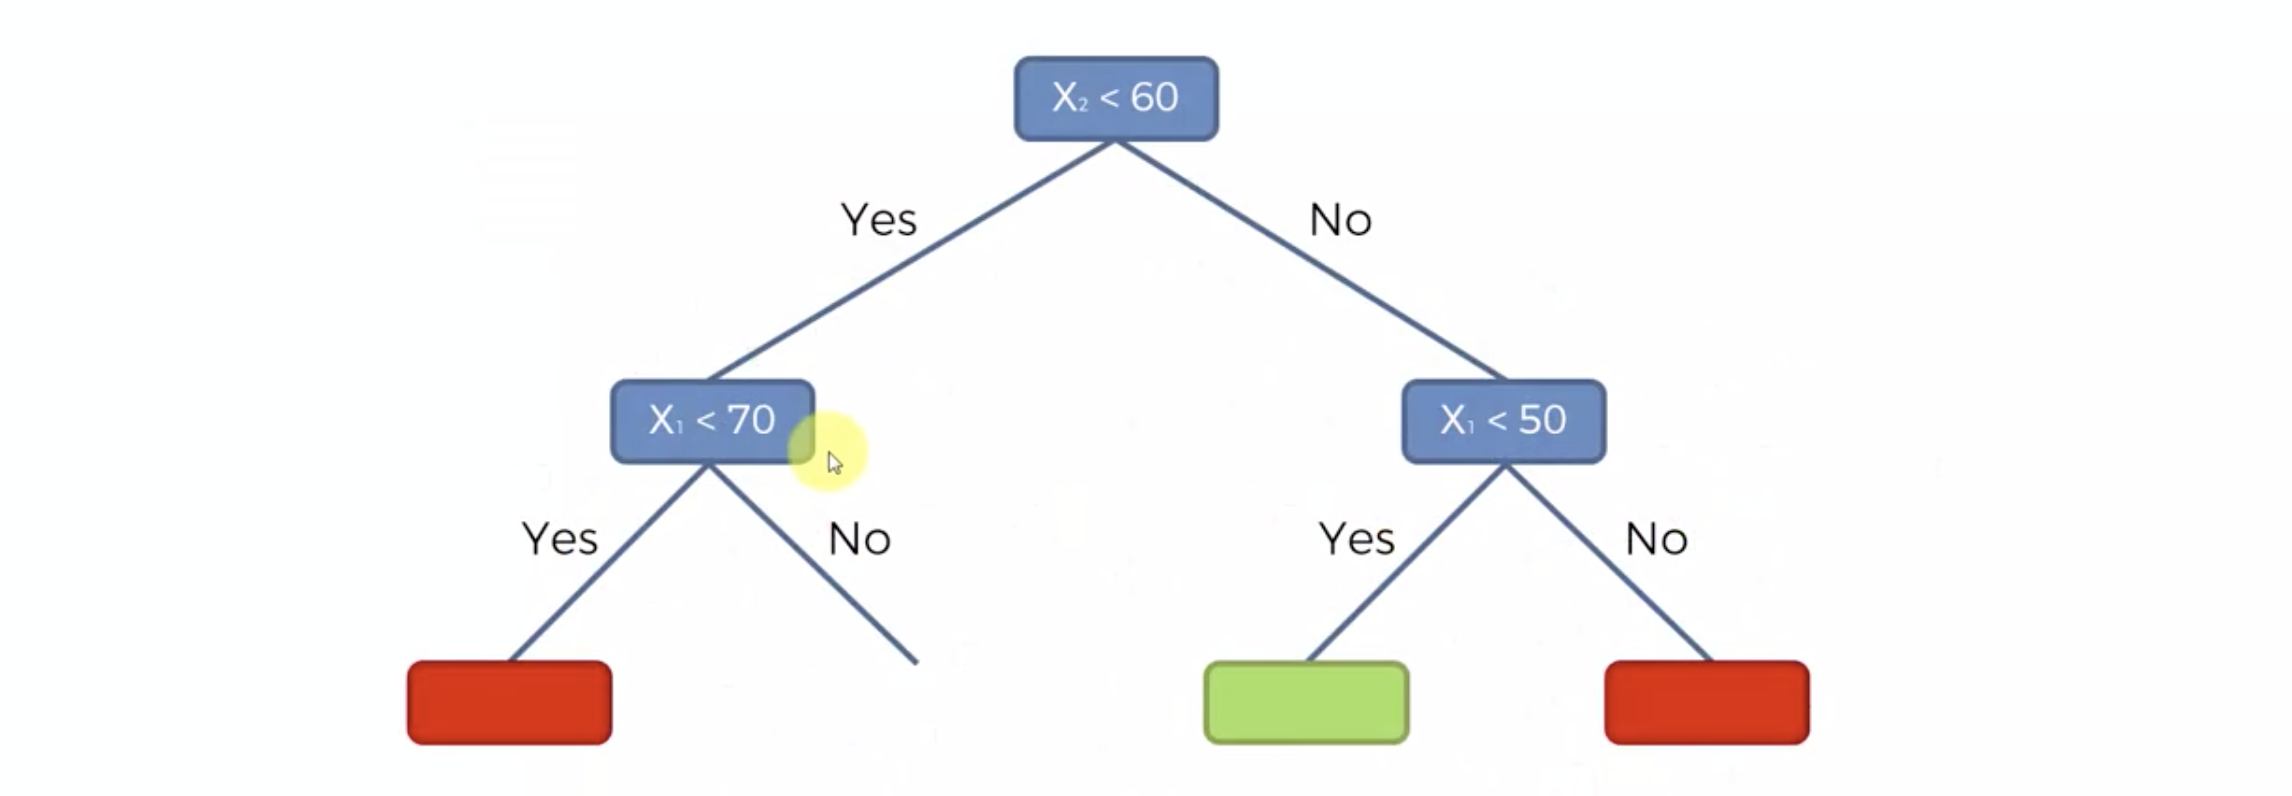

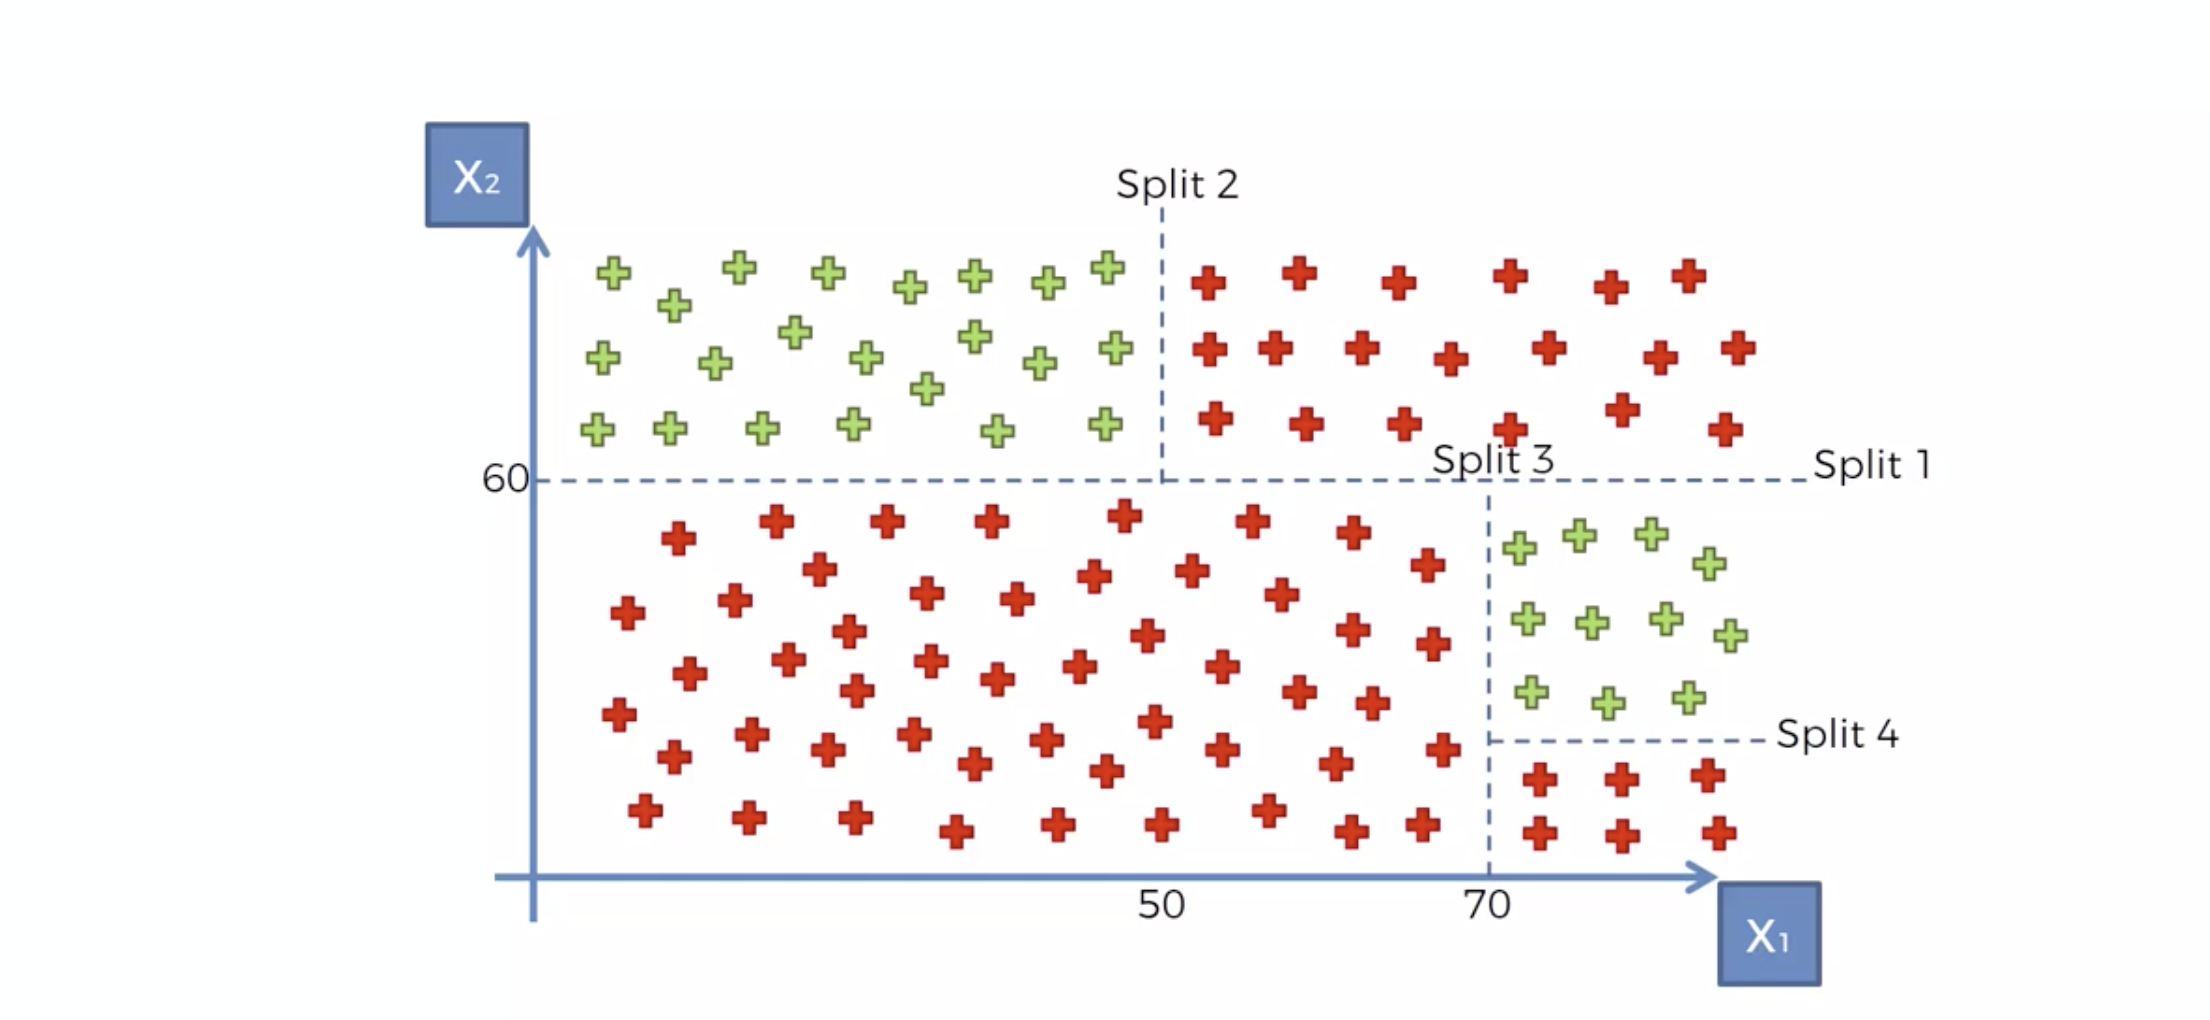

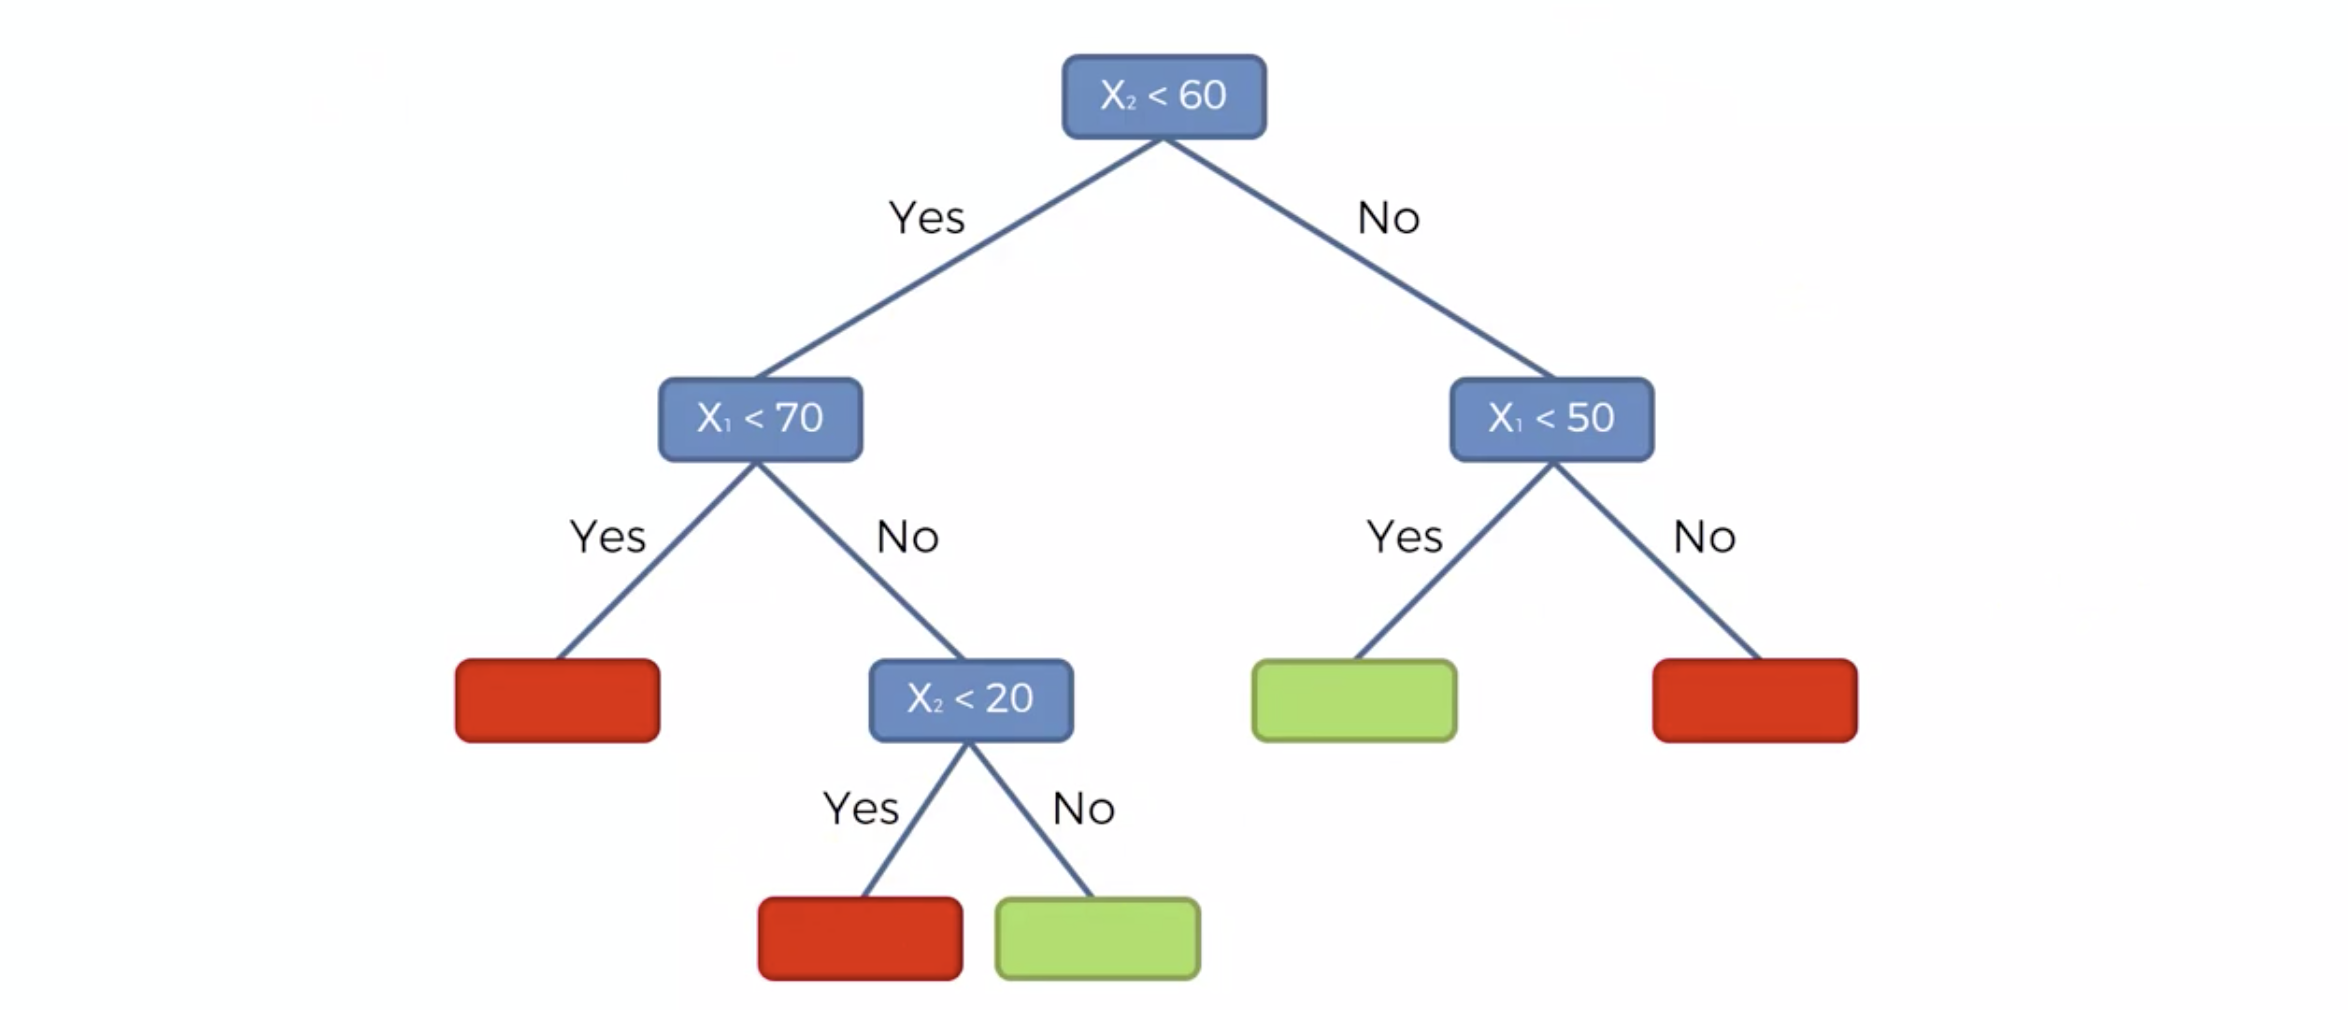

# lib와 데이터 로딩

In [2]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


import warnings
warnings.filterwarnings('ignore')

In [3]:
data_path = 'datas_ml/Social_Network_Ads.csv'
df = pd.read_csv(data_path)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [5]:
y = df['Purchased']

In [13]:
X = df.loc[:, ['Gender', 'Age', 'EstimatedSalary']]

In [22]:
# 방법 1: map 사용 (가장 직관적)
X['Gender'] = X['Gender'].map({'Male': 0, 'Female': 1})
# 방법 2
# X['Gender'] = X['Gender'].replace({'Male': 0, 'Female': 1})

In [23]:
X.head()

,Gender,Age,EstimatedSalary
0,0,19,19000
1,0,35,20000
2,1,26,43000
3,1,27,57000
4,0,19,76000


In [52]:
y.value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

- 의사결정 나무는 스케일을 할 필요가 없음

# train, test 데이터 분할

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

In [26]:
X_train.shape, y_train.shape

((300, 3), (300,))

In [27]:
X_test.shape, y_test.shape

((100, 3), (100,))

## 모델 학습

In [28]:
from sklearn.tree import DecisionTreeClassifier

In [29]:
classifier = DecisionTreeClassifier()

In [30]:
classifier.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [31]:
y_pred = classifier.predict(X_test)

In [32]:
from sklearn.metrics import classification_report, accuracy_score

# y_test: 실제 라벨, y_pred: 모델 예측 라벨
print("정확도:", accuracy_score(y_test, y_pred))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(y_test, y_pred))

정확도: 0.82

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        68
           1       0.73      0.69      0.71        32

    accuracy                           0.82       100
   macro avg       0.80      0.78      0.79       100
weighted avg       0.82      0.82      0.82       100



# 랜덤포레스트 모델
- DT는 실제로는 많이 사용하지 않고
- 개선한 모델을 사용함 - 랜덤 포레스트 또는 Xgboost

In [33]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
y_pred = rf_classifier.predict(X_test)

In [36]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [37]:
confusion_matrix(y_test, y_pred)

array([[65,  3],
       [ 6, 26]])

In [38]:
from sklearn.metrics import classification_report, accuracy_score

# y_test: 실제 라벨, y_pred: 모델 예측 라벨
print("정확도:", accuracy_score(y_test, y_pred))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(y_test, y_pred))

정확도: 0.91

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        68
           1       0.90      0.81      0.85        32

    accuracy                           0.91       100
   macro avg       0.91      0.88      0.89       100
weighted avg       0.91      0.91      0.91       100



# xgboost 모델 사용

In [40]:
%pip install -q xgboost

Note: you may need to restart the kernel to use updated packages.


In [41]:
from xgboost import XGBClassifier

In [48]:
xgb_classifier = XGBClassifier()

In [49]:
xgb_classifier.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [50]:
y_pred = xgb_classifier.predict(X_test)

In [51]:
from sklearn.metrics import classification_report, accuracy_score

# y_test: 실제 라벨, y_pred: 모델 예측 라벨
print("정확도:", accuracy_score(y_test, y_pred))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(y_test, y_pred))

정확도: 0.87

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.91      0.90      0.90        68
           1       0.79      0.81      0.80        32

    accuracy                           0.87       100
   macro avg       0.85      0.85      0.85       100
weighted avg       0.87      0.87      0.87       100

